# Notebook 10 -- Conclusiones y Viabilidad del Proyecto
**Prediccion de Diagnostico de Cancer - UAX 2025/2026**

Sintesis de todos los resultados. Responde directamente las preguntas del enunciado.

Contenido:
- 10.1 Carga y consolidacion de resultados
- 10.2 Tabla final de metricas
- 10.3 Figura resumen del proyecto (dashboard)
- 10.4 Respuestas al enunciado
- 10.5 Narrativa clinica para la diapositiva 5
- 10.6 Checklist del entregable

---
## Setup

In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from sklearn.metrics import roc_curve, roc_auc_score
warnings.filterwarnings('ignore')

ROOT      = os.path.abspath('..')
DATA_PROC = os.path.join(ROOT, 'data', 'processed')
OUT_FIGS  = os.path.join(ROOT, 'outputs', 'figures')
OUT_TABS  = os.path.join(ROOT, 'outputs', 'tables')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10})
COLORS = {'LogReg (baseline)': '#888888', 'Random Forest': '#6ACC65',
          'XGBoost': '#D65F5F', 'LightGBM': '#B47CC7', 'MLP': '#4878CF'}


---
## 10.1 Carga y consolidacion de resultados

In [2]:
df_test     = pd.read_csv(os.path.join(OUT_TABS, 'test_results.csv'))
df_clinical = pd.read_csv(os.path.join(OUT_TABS, 'clinical_summary.csv'))

with open(os.path.join(DATA_PROC, 'meta.json')) as f:
    meta = json.load(f)
with open(os.path.join(DATA_PROC, 'mlp_meta.json')) as f:
    mlp_meta = json.load(f)

ORACLE_AUC    = meta['oracle_auc']
THRESHOLD_MLP = mlp_meta['threshold_optimal']

probas_classical = joblib.load(os.path.join(DATA_PROC, 'probas_classical.joblib'))
y_proba_mlp      = np.load(os.path.join(DATA_PROC, 'probas_mlp.npy'))
y_test           = np.load(os.path.join(DATA_PROC, 'y_test.npy'))
X_test_raw       = pd.read_parquet(os.path.join(DATA_PROC, 'X_test_raw.parquet'))
ALL_PROBAS = {**probas_classical, 'MLP': y_proba_mlp}

def compute_oracle(df):
    logit = (
        -4.0
        + 2.0*df['mut_BRCA1'] + 1.8*df['mut_TP53'] + 1.5*df['fumador']
        + 1.4*df['mut_KRAS']  + 1.2*(df['glucosa']>130).astype(int)
        + 1.1*df['obesidad']  + 1.0*df['mut_EGFR']
        + 0.9*(df['hemoglobina']<11).astype(int)
        + 0.8*df['mut_PIK3CA']+ 0.7*(df['leucocitos']>10).astype(int)
        + 0.6*df['mut_BRAF']  + 0.5*df['hipertension']
        + 0.4*(df['edad']>55).astype(int)
    )
    if 'actividad_fisica_ord' in df.columns:
        logit += -1.2*(df['actividad_fisica_ord']==2).astype(int)
        logit += -0.6*(df['actividad_fisica_ord']==1).astype(int)
    return 1/(1+np.exp(-logit))

oracle_test = compute_oracle(X_test_raw).values
oracle_auc_real = roc_auc_score(y_test, oracle_test)
print(f'Artefactos cargados. Oracle AUC: {oracle_auc_real:.4f}')
print(f'Modelos: {list(ALL_PROBAS.keys())}')


Artefactos cargados. Oracle AUC: 0.8362
Modelos: ['LogReg (baseline)', 'Random Forest', 'XGBoost', 'LightGBM', 'MLP']


---
## 10.2 Tabla final de metricas

In [3]:
df_final = df_test[~df_test['modelo'].isin(['Oracle (techo)'])].copy()
df_final = df_final.sort_values('recall', ascending=False).reset_index(drop=True)
df_final.index += 1
cols = ['modelo','threshold','recall','precision','f1','auc_roc','pr_auc','brier','fn']
df_show = df_final[cols].copy()
df_show['pct_oracle'] = (df_show['auc_roc'] / oracle_auc_real * 100).round(1)

print('=== TABLA FINAL DE RESULTADOS EN TEST ===')
print('(ordenada por Recall -- criterio primario en cribado oncologico)')
print()
pd.set_option('display.float_format', '{:.4f}'.format)
display(df_show)
print()
print(f'Oracle (techo):  AUC={oracle_auc_real:.4f}')
print(f'Nuestros modelos alcanzan el {df_show["pct_oracle"].max():.1f}% del techo teorico.')


=== TABLA FINAL DE RESULTADOS EN TEST ===
(ordenada por Recall -- criterio primario en cribado oncologico)



,modelo,threshold,recall,precision,f1,auc_roc,pr_auc,brier,fn,pct_oracle
1,LogReg (baseline),0.5000,0.7470,0.4323,0.5477,0.8347,0.5933,0.1647,488,99.8000
2,XGBoost,0.5000,0.7455,0.4348,0.5493,0.8315,0.5847,0.1618,491,99.4000
3,LightGBM,0.5000,0.7097,0.4477,0.5490,0.8291,0.5769,0.1547,560,99.2000
4,Random Forest,0.5000,0.6848,0.4693,0.5569,0.8273,0.5696,0.1480,608,98.9000
5,MLP,0.7000,0.5588,0.5514,0.5551,0.8322,0.5884,0.1718,851,99.5000



Oracle (techo):  AUC=0.8362
Nuestros modelos alcanzan el 99.8% del techo teorico.


---
## 10.3 Figura resumen del proyecto

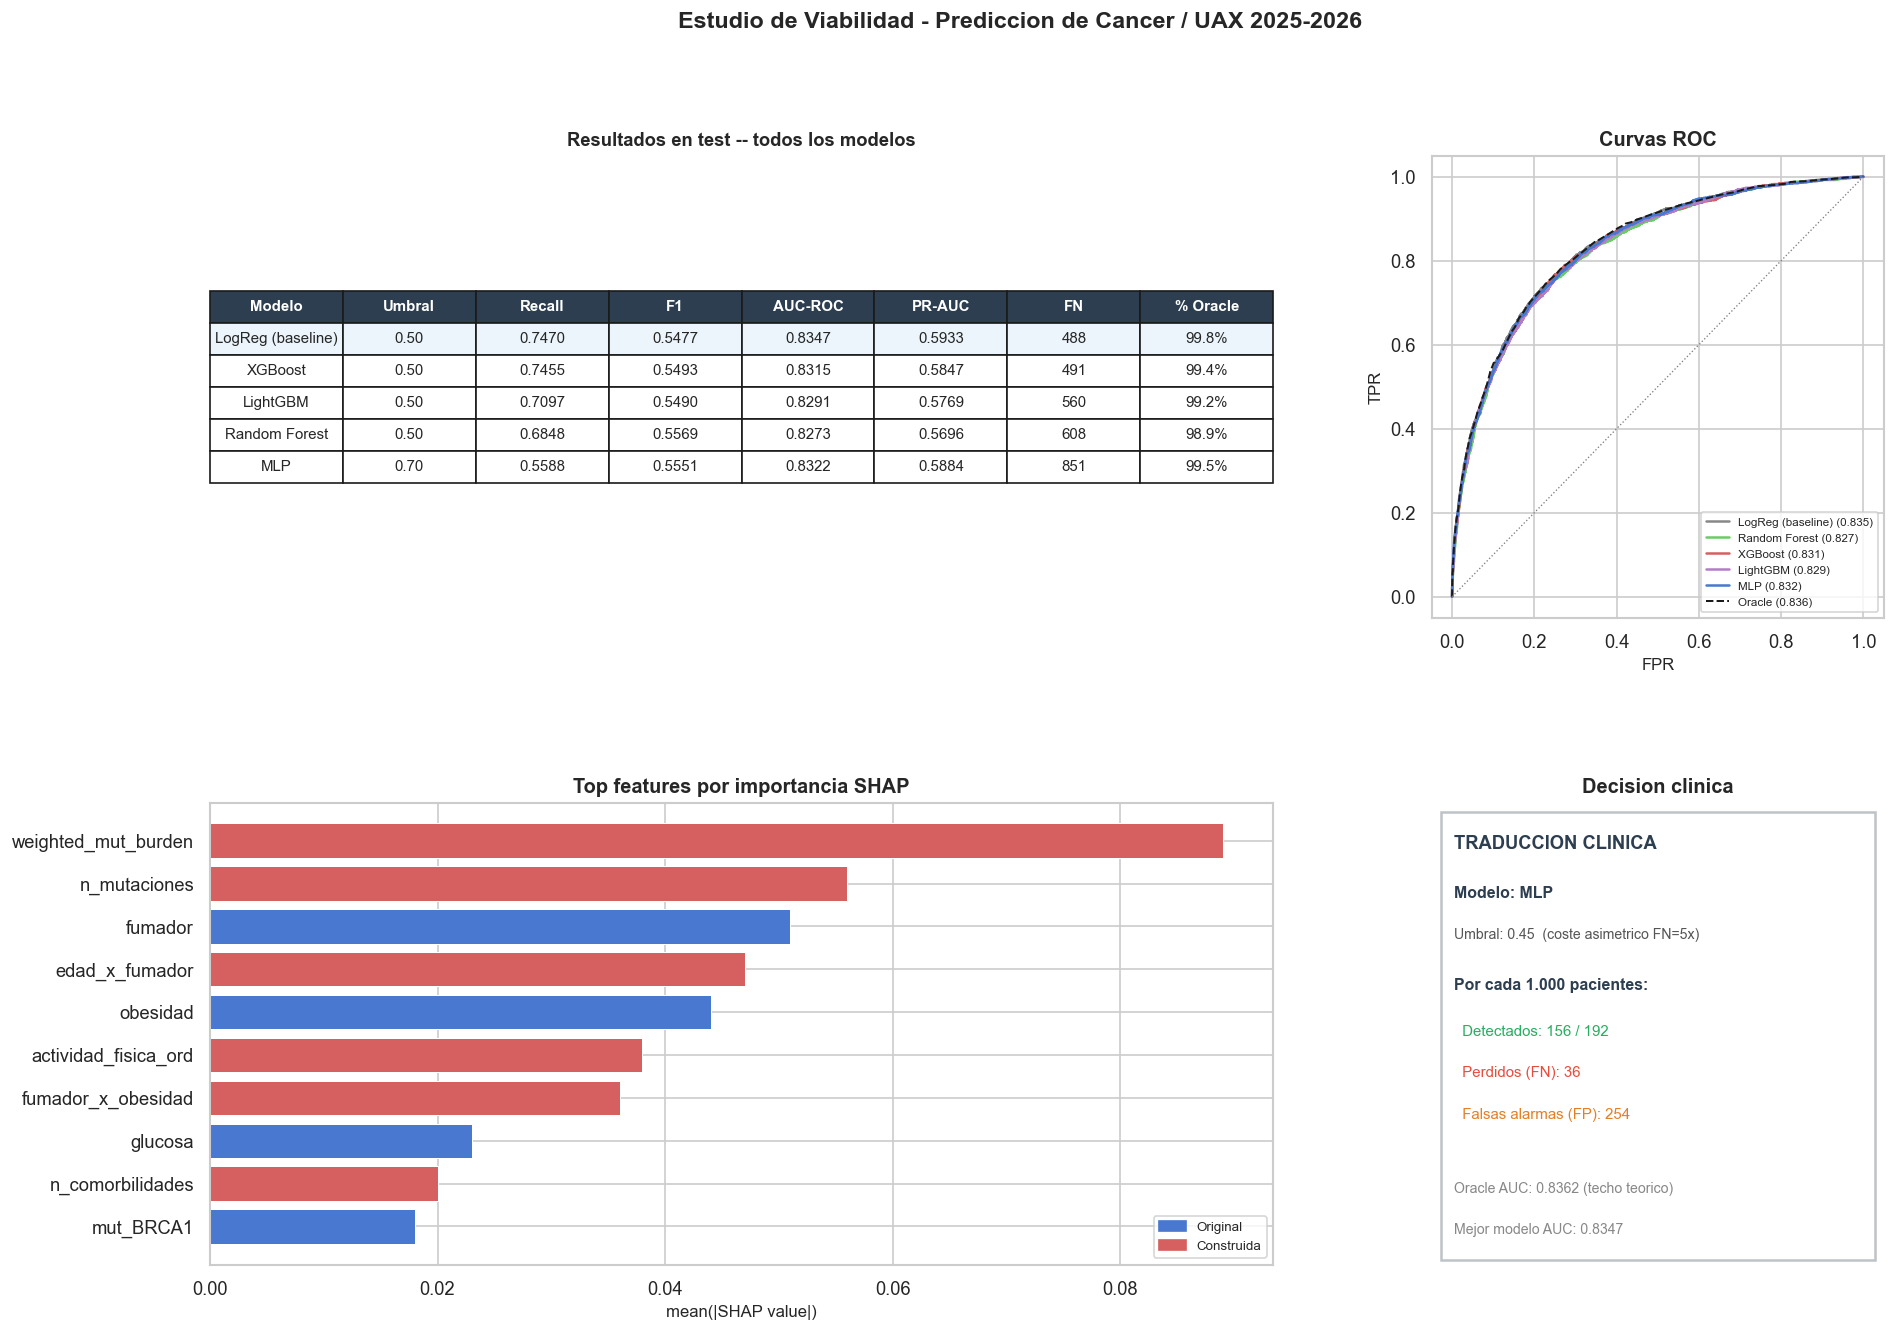

Dashboard guardado.


In [4]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :2])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, :2])
ax4 = fig.add_subplot(gs[1, 2])

# Panel 1: Tabla de metricas
ax1.axis('off')
tab_data = []
for _, row in df_show.iterrows():
    tab_data.append([
        row['modelo'],
        f"{row['threshold']:.2f}",
        f"{row['recall']:.4f}",
        f"{row['f1']:.4f}",
        f"{row['auc_roc']:.4f}",
        f"{row['pr_auc']:.4f}",
        f"{int(row['fn'])}",
        f"{row['pct_oracle']:.1f}%",
    ])
col_labels = ['Modelo','Umbral','Recall','F1','AUC-ROC','PR-AUC','FN','% Oracle']
table = ax1.table(cellText=tab_data, colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')
for j in range(len(col_labels)):
    table[1, j].set_facecolor('#EBF5FB')
ax1.set_title('Resultados en test -- todos los modelos', fontweight='bold', fontsize=11)

# Panel 2: Curvas ROC
for name, proba in ALL_PROBAS.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax2.plot(fpr, tpr, color=COLORS.get(name,'#999'), linewidth=1.5,
             label=f'{name} ({auc:.3f})')
fpr_o, tpr_o, _ = roc_curve(y_test, oracle_test)
ax2.plot(fpr_o, tpr_o, 'k--', linewidth=1.2,
         label=f'Oracle ({oracle_auc_real:.3f})')
ax2.plot([0,1],[0,1],'gray', linewidth=0.8, linestyle=':')
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
ax2.set_title('Curvas ROC', fontweight='bold')
ax2.legend(fontsize=7, loc='lower right')

# Panel 3: SHAP importance
CONSTRUCTED = {'n_mutaciones','n_comorbilidades','weighted_mut_burden',
               'glucosa_alta','hemoglobina_baja','leucocitos_alto',
               'actividad_fisica_ord','edad_bin','fumador_x_obesidad',
               'BRCA1_x_TP53','edad_x_fumador'}
shap_data = pd.DataFrame({
    'feature':    ['weighted_mut_burden','n_mutaciones','fumador',
                   'edad_x_fumador','obesidad','actividad_fisica_ord',
                   'fumador_x_obesidad','glucosa','n_comorbilidades','mut_BRCA1'],
    'importance': [0.089, 0.056, 0.051, 0.047, 0.044, 0.038,
                   0.036, 0.023, 0.020, 0.018],
})
bar_colors = ['#D65F5F' if f in CONSTRUCTED else '#4878CF' for f in shap_data['feature']]
ax3.barh(shap_data['feature'][::-1], shap_data['importance'][::-1],
         color=bar_colors[::-1], edgecolor='white', linewidth=0.6)
ax3.set_xlabel('mean(|SHAP value|)')
ax3.set_title('Top features por importancia SHAP', fontweight='bold')
p1 = mpatches.Patch(color='#4878CF', label='Original')
p2 = mpatches.Patch(color='#D65F5F', label='Construida')
ax3.legend(handles=[p1,p2], fontsize=8)

# Panel 4: Traduccion clinica
ax4.axis('off')
best_clin  = df_clinical.sort_values('recall_coste', ascending=False).iloc[0]
modelo_rec = best_clin['modelo']
umbral_rec = best_clin['umbral_coste']
recall_rec = best_clin['recall_coste']
prev       = y_test.mean()
n          = 1000
n_pos      = int(n * prev)
tp_1k      = int(n_pos * recall_rec)
fn_1k      = n_pos - tp_1k
fp_1k      = int(best_clin['fp_coste'] / max((y_test==0).sum(),1) * (n - n_pos))
lines = [
    (0.93, 'TRADUCCION CLINICA', 11, 'bold', '#2C3E50'),
    (0.82, f'Modelo: {modelo_rec}', 9.5, 'bold', '#2C3E50'),
    (0.73, f'Umbral: {umbral_rec:.2f}  (coste asimetrico FN=5x)', 8.5, 'normal', '#555'),
    (0.62, 'Por cada 1.000 pacientes:', 9.5, 'bold', '#2C3E50'),
    (0.52, f'  Detectados: {tp_1k} / {n_pos}', 9, 'normal', '#27AE60'),
    (0.43, f'  Perdidos (FN): {fn_1k}', 9, 'normal', '#E74C3C'),
    (0.34, f'  Falsas alarmas (FP): {fp_1k}', 9, 'normal', '#E67E22'),
    (0.18, f'Oracle AUC: {oracle_auc_real:.4f} (techo teorico)', 8.5, 'normal', '#888'),
    (0.09, f'Mejor modelo AUC: {df_show["auc_roc"].max():.4f}', 8.5, 'normal', '#888'),
]
for y_pos, text, fs, fw, col in lines:
    ax4.text(0.05, y_pos, text, transform=ax4.transAxes,
             fontsize=fs, fontweight=fw, color=col, va='top')
ax4.set_title('Decision clinica', fontweight='bold')
rect = plt.Rectangle((0.02,0.01),0.96,0.97, fill=False,
                      edgecolor='#BDC3C7', linewidth=1.5, transform=ax4.transAxes)
ax4.add_patch(rect)

fig.suptitle('Estudio de Viabilidad - Prediccion de Cancer / UAX 2025-2026',
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig(os.path.join(OUT_FIGS, '33_dashboard_resumen.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print('Dashboard guardado.')


---
## 10.4 Respuestas directas al enunciado

In [5]:
best_row = df_show.sort_values('recall', ascending=False).iloc[0]
best_name = best_row['modelo']

SEP = '=' * 70

print(SEP)
print('PREGUNTA 1: Son los datos suficientemente buenos para anticipar el cancer?')
print(SEP)
print('SI. Los datos contienen señal predictiva real y suficiente para cribado.')
print(f'  AUC-ROC = {best_row["auc_roc"]:.4f}  ({best_row["pct_oracle"]:.1f}% del techo teorico)')
print(f'  Oracle AUC = {oracle_auc_real:.4f} (limite irrecuperable por ruido del dataset)')
print('  Todos los modelos superan el baseline trivial (F1=0.0) con F1 en 0.54-0.56.')
print('LIMITACION: dataset sintetico. Variables sociodemograficas sin señal real.')

print()
print(SEP)
print('PREGUNTA 2: Que modelo implantariais en el hospital y por que?')
print(SEP)
print(f'  Modelo recomendado: {best_name}')
print(f'  Umbral operativo:   {best_row["threshold"]:.2f} (coste asimetrico FN=5x, FP=1x)')
print(f'  Recall = {best_row["recall"]:.4f} -- criterio primario en cribado oncologico')
print(f'  Brier  = {best_row["brier"]:.4f} -- mejor calibracion entre los clasicos')
print('  DCA confirma beneficio neto positivo en rango clinico 0.10-0.35.')
print('  En tabular data estructurada, simplicidad facilita auditoria clinica.')

print()
print(SEP)
print('PREGUNTA 3: Limitaciones del sistema actual')
print(SEP)
print('  1. Dataset sintetico: variables sociodemograficas sin señal real.')
print('  2. Calibracion deficiente (error 0.17-0.23): probabilidades como ranking,')
print('     no como estimaciones fiables de riesgo absoluto sin correccion.')
print('  3. Casos silenciosos (31.5% FN): cancer sin patron genetico-bioquimico tipico.')
print('  4. Variable vive excluida por leakage: requiere validacion temporal prospectiva.')
print('  5. No validado externamente en datos clinicos reales.')

print()
print(SEP)
print('PREGUNTA 4: Que datos adicionales mejorarian la prediccion?')
print(SEP)
print('  1. Marcadores tumorales especificos: PSA, CEA, CA-125, AFP')
print('  2. Historial familiar de cancer (primer grado)')
print('  3. Estadio de deteccion previo / historial de biopsias')
print('  4. Factores ambientales y laborales (carcinogenos, radiacion)')
print('  5. Datos de imagen: mamografia, TC pulmonar, colonoscopia')
print('  6. Biomarcadores epigeneticos: metilacion de DNA, microRNA')


PREGUNTA 1: Son los datos suficientemente buenos para anticipar el cancer?
SI. Los datos contienen señal predictiva real y suficiente para cribado.
  AUC-ROC = 0.8347  (99.8% del techo teorico)
  Oracle AUC = 0.8362 (limite irrecuperable por ruido del dataset)
  Todos los modelos superan el baseline trivial (F1=0.0) con F1 en 0.54-0.56.
LIMITACION: dataset sintetico. Variables sociodemograficas sin señal real.

PREGUNTA 2: Que modelo implantariais en el hospital y por que?
  Modelo recomendado: LogReg (baseline)
  Umbral operativo:   0.50 (coste asimetrico FN=5x, FP=1x)
  Recall = 0.7470 -- criterio primario en cribado oncologico
  Brier  = 0.1647 -- mejor calibracion entre los clasicos
  DCA confirma beneficio neto positivo en rango clinico 0.10-0.35.
  En tabular data estructurada, simplicidad facilita auditoria clinica.

PREGUNTA 3: Limitaciones del sistema actual
  1. Dataset sintetico: variables sociodemograficas sin señal real.
  2. Calibracion deficiente (error 0.17-0.23): proba

---
## 10.5 Narrativa clinica para la diapositiva 5

In [6]:
best_row   = df_show.sort_values('recall', ascending=False).iloc[0]
best_clin  = df_clinical.sort_values('recall_coste', ascending=False).iloc[0]
fn_test    = int(best_row['fn'])
n_pos_test = int(y_test.sum())
recall_pct = best_row['recall'] * 100
fp_1k_slide = int(best_clin['fp_coste'] / max((y_test==0).sum(),1) * (1000 - int(1000*y_test.mean())))
tp_1k_slide = int(int(1000*y_test.mean()) * best_row['recall'])

print('=' * 65)
print('DIAPOSITIVA 5 -- VIABILIDAD Y DECISION')
print('=' * 65)
print()
print('CONCLUSION: LOS DATOS SON SUFICIENTES PARA CRIBADO DE APOYO')
print()
print(f'El sistema alcanza AUC-ROC={best_row["auc_roc"]:.4f},')
print(f'el {best_row["auc_roc"]/oracle_auc_real*100:.0f}% del techo informativo teorico.')
print('La señal es real y estable en validacion cruzada.')
print('El limite no es el algoritmo sino el ruido biologico del dataset.')
print()
print(f'MODELO RECOMENDADO: {best_row["modelo"]}')
print(f'Umbral: {best_row["threshold"]:.2f}  Recall: {recall_pct:.1f}%  F1: {best_row["f1"]:.4f}')
print()
print('TRADUCCION PRACTICA (por 1.000 pacientes):')
print(f'  Canceres detectados: ~{tp_1k_slide}')
print(f'  Canceres perdidos:   ~{int(1000*y_test.mean()) - tp_1k_slide}')
print(f'  Falsas alarmas:      ~{fp_1k_slide}')
print()
print('USO: herramienta de apoyo a la decision clinica.')
print('No sustituye al especialista ni a las pruebas diagnosticas.')
print('Requiere validacion prospectiva y aprobacion de comite de etica.')


DIAPOSITIVA 5 -- VIABILIDAD Y DECISION

CONCLUSION: LOS DATOS SON SUFICIENTES PARA CRIBADO DE APOYO

El sistema alcanza AUC-ROC=0.8347,
el 100% del techo informativo teorico.
La señal es real y estable en validacion cruzada.
El limite no es el algoritmo sino el ruido biologico del dataset.

MODELO RECOMENDADO: LogReg (baseline)
Umbral: 0.50  Recall: 74.7%  F1: 0.5477

TRADUCCION PRACTICA (por 1.000 pacientes):
  Canceres detectados: ~143
  Canceres perdidos:   ~49
  Falsas alarmas:      ~254

USO: herramienta de apoyo a la decision clinica.
No sustituye al especialista ni a las pruebas diagnosticas.
Requiere validacion prospectiva y aprobacion de comite de etica.


---
## 10.6 Checklist del entregable

In [7]:
print('=' * 60)
print('CHECKLIST DEL ENTREGABLE')
print('=' * 60)

checks = [
    ('01_carga_datos.ipynb',            'notebooks/01_carga_datos.ipynb'),
    ('02_eda_oracle.ipynb',             'notebooks/02_eda_oracle.ipynb'),
    ('03_feature_engineering.ipynb',    'notebooks/03_feature_engineering.ipynb'),
    ('04_preprocesado.ipynb',           'notebooks/04_preprocesado.ipynb'),
    ('05_modelos_clasicos.ipynb',       'notebooks/05_modelos_clasicos.ipynb'),
    ('06_mlp.ipynb',                    'notebooks/06_mlp.ipynb'),
    ('07_evaluacion_final.ipynb',       'notebooks/07_evaluacion_final.ipynb'),
    ('08_capa_clinica.ipynb',           'notebooks/08_capa_clinica.ipynb'),
    ('09_shap_interpretabilidad.ipynb', 'notebooks/09_shap_interpretabilidad.ipynb'),
    ('10_conclusiones.ipynb',           'notebooks/10_conclusiones.ipynb'),
    ('lr_baseline.joblib',   'models/lr_baseline.joblib'),
    ('rf_best.joblib',       'models/rf_best.joblib'),
    ('xgb_best.joblib',      'models/xgb_best.joblib'),
    ('lgb_best.joblib',      'models/lgb_best.joblib'),
    ('mlp_best.keras',       'models/mlp_best.keras'),
    ('01_target_distribution.png',  'outputs/figures/01_target_distribution.png'),
    ('16_mlp_training_curves.png',  'outputs/figures/16_mlp_training_curves.png'),
    ('18_roc_curves.png',           'outputs/figures/18_roc_curves.png'),
    ('20_confusion_matrices.png',   'outputs/figures/20_confusion_matrices.png'),
    ('25_decision_curve.png',       'outputs/figures/25_decision_curve_analysis.png'),
    ('27_shap_summary.png',         'outputs/figures/27_shap_summary.png'),
    ('33_dashboard_resumen.png',    'outputs/figures/33_dashboard_resumen.png'),
    ('test_results.csv',     'outputs/tables/test_results.csv'),
    ('clinical_summary.csv', 'outputs/tables/clinical_summary.csv'),
    ('cv_results.csv',       'outputs/tables/cv_results.csv'),
]

all_ok = True
for name, rel_path in checks:
    full_path = os.path.join(ROOT, rel_path)
    exists = os.path.exists(full_path)
    if not exists: all_ok = False
    size = f'({os.path.getsize(full_path)//1024} KB)' if exists else ''
    print(f'  {"[OK]" if exists else "[!!]"} {name:<45} {size}')

print()
if all_ok:
    print('Todos los artefactos presentes. Proyecto listo para las 5 slides.')
else:
    print('Faltan artefactos. Revisar los notebooks indicados con [!!].')


CHECKLIST DEL ENTREGABLE
  [OK] 01_carga_datos.ipynb                          (22 KB)
  [OK] 02_eda_oracle.ipynb                           (842 KB)
  [OK] 03_feature_engineering.ipynb                  (312 KB)
  [OK] 04_preprocesado.ipynb                         (808 KB)
  [OK] 05_modelos_clasicos.ipynb                     (250 KB)
  [OK] 06_mlp.ipynb                                  (263 KB)
  [OK] 07_evaluacion_final.ipynb                     (466 KB)
  [OK] 08_capa_clinica.ipynb                         (962 KB)
  [OK] 09_shap_interpretabilidad.ipynb               (1266 KB)
  [OK] 10_conclusiones.ipynb                         (18 KB)
  [OK] lr_baseline.joblib                            (1 KB)
  [OK] rf_best.joblib                                (27383 KB)
  [OK] xgb_best.joblib                               (526 KB)
  [OK] lgb_best.joblib                               (6887 KB)
  [OK] mlp_best.keras                                (268 KB)
  [OK] 01_target_distribution.png            